# CBAM ResNet18 with NCA and kNN Classification

This model leverages the powerful feature extraction capabilities of a fine-tuned CBAM-enhanced ResNet18. The traditional CNN classification head is replaced by an architecture similar to the ExMPLPQ model: extracted features are reduced using NCA and classified by kNN.

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights


In [2]:
import refactor.src.data as data
import refactor.src.models as models
import refactor.src.trainer as trainer
import refactor.src.evaluator as evaluator

## Data Acquisition & Processing

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


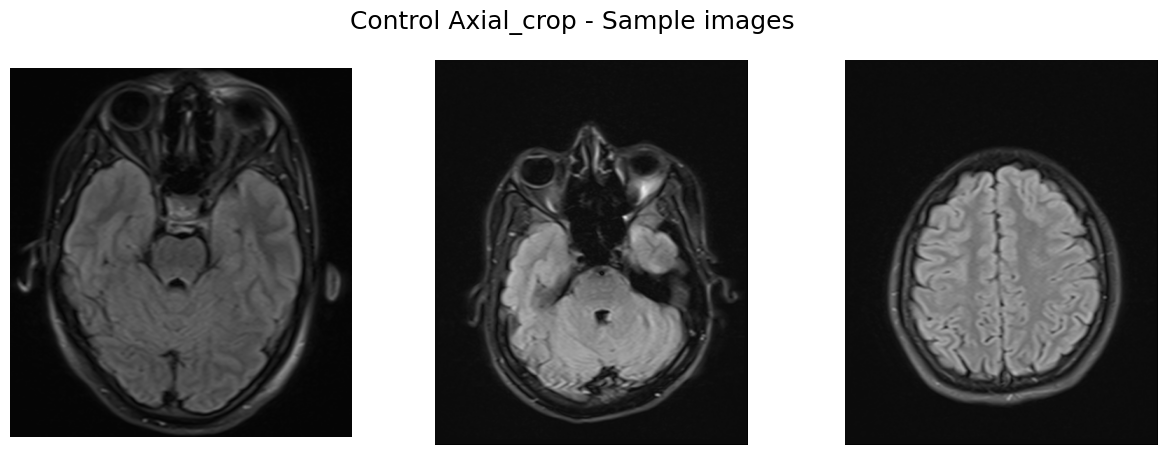

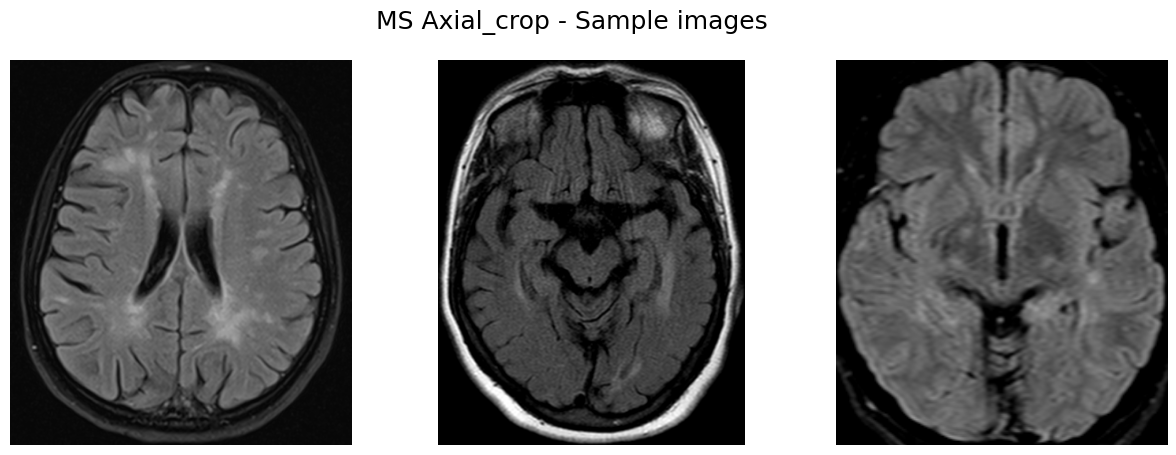

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Training samples: 1321, Testing samples: 331


In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

train_loader, test_loader, test_data = data.get_data_loaders(image_paths, labels, train_transform, test_transform)

## Model Instantiation

There are several different CBAM model variations relating to different CBAM placement options. These options are as follows:
- **architecture = "cbam_end"** : Single CBAM before the classifier (after layer 4)
- **architecture = "cbam_block_pre"**: CBAM built into each BasicBlock (before the shortcut)
- **architecture = "cbam_block_post"**: CBAM built into each BasicBlock (after the shortcut)

In [4]:
# Using simplest CBAM model variation with a single CBAM module at the end of ResNet18 before classification
model = models.get_model(architecture="cbam_end")

get_model()>>> 
 CBAMResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

## Model Training

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**Loss & Acc**: Training metrics averaged over an epoch: Loss is mean training loss, Acc is training accuracy for that epoch.<br>

In [5]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 10,
        "lr": 1e-3,
        "parameters": "head",          # train only classifier head
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 5,
        "lr": 1e-5,                    # lower LR for fine-tuning
        "parameters": "all",           # train backbone + head
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}


[base] Epoch 1/10 - Loss: 0.5778 - Acc: 0.7101
[base] Epoch 2/10 - Loss: 0.4632 - Acc: 0.7873
[base] Epoch 3/10 - Loss: 0.4300 - Acc: 0.8077
[base] Epoch 4/10 - Loss: 0.3892 - Acc: 0.8395
[base] Epoch 5/10 - Loss: 0.3802 - Acc: 0.8372
[base] Epoch 6/10 - Loss: 0.3569 - Acc: 0.8441
[base] Epoch 7/10 - Loss: 0.3465 - Acc: 0.8478
[base] Epoch 8/10 - Loss: 0.3629 - Acc: 0.8433
[base] Epoch 9/10 - Loss: 0.3430 - Acc: 0.8600
[base] Epoch 10/10 - Loss: 0.3816 - Acc: 0.8274


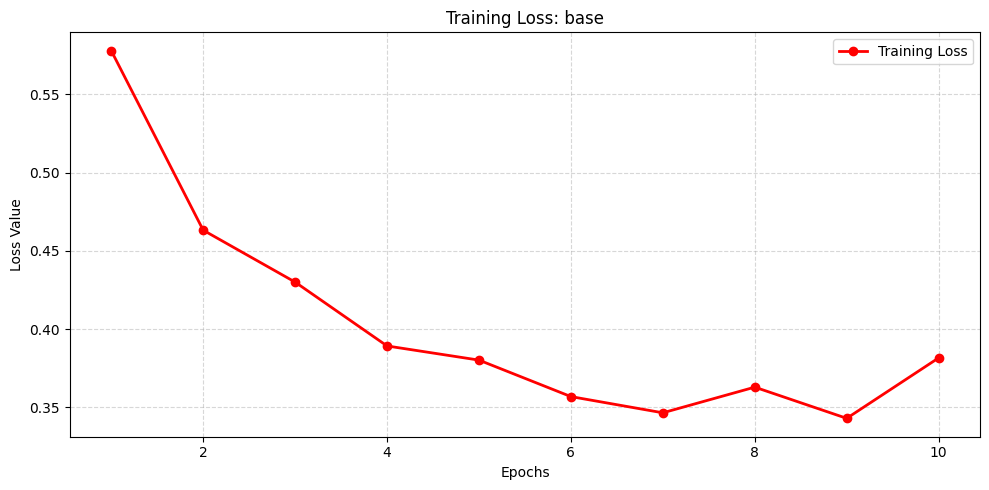

In [6]:
# Base training phase - only training classifier head
train_losses, train_accuracies = trainer.train_model(model, train_loader, config_name="base", train_configs=train_configs)
trainer.plot(train_losses, train_accuracies, config_name="base")

[fine_tune] Epoch 1/5 - Loss: 0.3002 - Acc: 0.8706
[fine_tune] Epoch 2/5 - Loss: 0.2576 - Acc: 0.8933
[fine_tune] Epoch 3/5 - Loss: 0.2140 - Acc: 0.9137
[fine_tune] Epoch 4/5 - Loss: 0.1708 - Acc: 0.9349
[fine_tune] Epoch 5/5 - Loss: 0.1615 - Acc: 0.9311


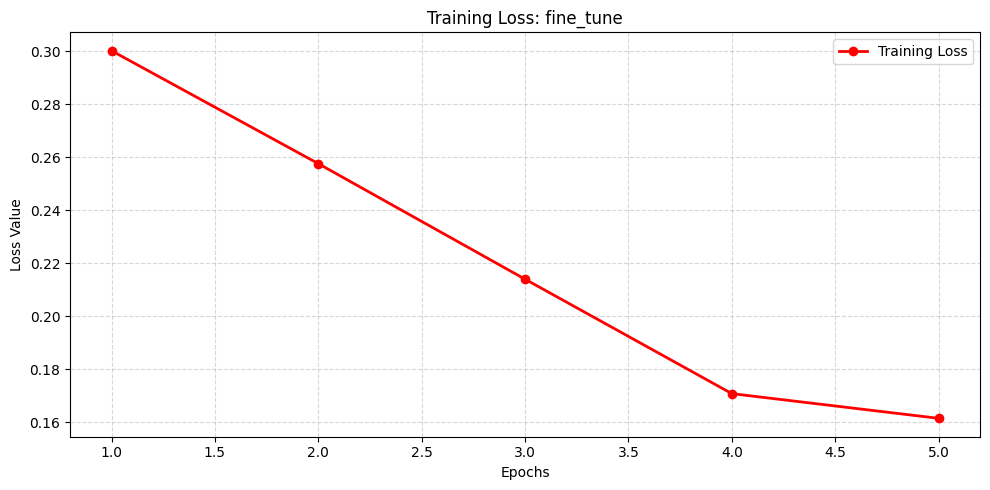

In [7]:
# Fine-tuning phase - training entire model
train_losses, train_accuracies = trainer.train_model(model, train_loader, config_name="fine_tune", train_configs=train_configs)
trainer.plot(train_losses, train_accuracies, config_name="fine_tune")

In [8]:
trainer.save_weights(model, WEIGHTS_DIR / "full_nca_test.pth")

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\full_nca_test.pth


In [5]:
model = models.get_model(architecture="cbam_end")
model = trainer.load_weights(model, WEIGHTS_DIR / "full_nca_test.pth")

get_model()>>> 
 CBAMResNet18(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

## Feature Extraction, NCA, and kNN Classification
This section implements the new, adapted pipeline using the trained CNN as a feature extractor, followed by feature selection and kNN classification.

In [6]:
# Extract features
X_train_features, y_train_features_labels = trainer.get_features(model, train_loader)
X_test_features, y_test_features_labels = trainer.get_features(model, test_loader)

### NCA

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

In [13]:
TARGET = 256 # Desired reduced feature dimension

X_train_selected, X_test_selected = trainer.get_nca_features(X_train_scaled, y_train_features_labels, X_test_scaled, TARGET_DIM=TARGET)


get_nca_features()>>> Fitting NCA to reduce 512 features to 256...
get_nca_features()>>> Reduced Train Feature Shape: (1321, 256)
get_nca_features()>>> Reduced Test Feature Shape: (331, 256)


## KNN

In [18]:
n = 3  # Number of neighbours for kNN

knn = trainer.get_and_train_knn(X_train_selected, y_train_features_labels, NUM_NEIGHBOURS=n)

y_pred = evaluator.predict_knn(knn, X_test_selected)

get_and_train_knn()>>> Training kNN classifier on NCA selected deep features...
predict_knn()>>> Predicting test set labels using kNN classifier...


## Model Evaluation
**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

In [19]:
evaluator.evaluate_model(test_loader=test_loader, y_true=y_test_features_labels, y_pred=y_pred)

Accuracy: 0.8761329305135952
Precision: 0.9009009009009009
Recall: 0.7692307692307693
Confusion Matrix:
 [[190  11]
 [ 30 100]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90       201
           1       0.90      0.77      0.83       130

    accuracy                           0.88       331
   macro avg       0.88      0.86      0.87       331
weighted avg       0.88      0.88      0.87       331



(0.8761329305135952,
 0.9009009009009009,
 0.7692307692307693,
 array([[190,  11],
        [ 30, 100]]),
 '              precision    recall  f1-score   support\n\n           0       0.86      0.95      0.90       201\n           1       0.90      0.77      0.83       130\n\n    accuracy                           0.88       331\n   macro avg       0.88      0.86      0.87       331\nweighted avg       0.88      0.88      0.87       331\n')

## Model Prediction Visualisation

need to work out how to visualise using knn classifier (do we need model or just knn?)